# Import Library

In [152]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from matplotlib import pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

!pip install kneed
from kneed import KneeLocator

# Data Preprocessing

In [153]:
# load dataset and show the first five sample
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/COVID-19%20Coronavirus%20(2).csv"
df = pd.read_csv(url)
df.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438


In [154]:
# rename some columns
df = df.rename(columns={"ISO 3166-1 alpha-3 CODE": "iso3", "Tot\xa0Cases//1M pop": "cases_per_one_million", "Tot\xa0Deaths/1M pop": "deaths_per_one_million"})
df.head()

,Country,Other names,iso3,Population,Continent,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438


In [155]:
# describe data
df.describe()

,Population,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage
count,2.250000e+02,2.250000e+02,2.250000e+02,225.000000,225.000000,225.000000
mean,3.507321e+07,2.184781e+06,2.744813e+04,136900.373333,1096.715556,1.444125
std,1.392418e+08,7.275938e+06,9.689177e+04,145060.340289,1195.715543,1.741728
min,8.050000e+02,1.000000e+00,0.000000e+00,9.000000,0.000000,0.000000
25%,5.665570e+05,2.407100e+04,1.890000e+02,11384.000000,123.000000,0.511291
50%,5.827911e+06,1.639360e+05,1.965000e+03,88987.000000,708.000000,1.036905
75%,2.190585e+07,1.092547e+06,1.366000e+04,223335.000000,1795.000000,1.977017
max,1.439324e+09,8.183905e+07,1.008222e+06,696044.000000,6286.000000,18.151787


In [156]:
# Check for info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 225 non-null    object 
 1   Other names             224 non-null    object 
 2   iso3                    225 non-null    object 
 3   Population              225 non-null    int64  
 4   Continent               225 non-null    object 
 5   Total Cases             225 non-null    int64  
 6   Total Deaths            225 non-null    int64  
 7   cases_per_one_million   225 non-null    int64  
 8   deaths_per_one_million  225 non-null    int64  
 9   Death percentage        225 non-null    float64
dtypes: float64(1), int64(5), object(4)
memory usage: 17.7+ KB


In [157]:
# check for missing values
df.isnull().sum()

Country                   0
Other names               1
iso3                      0
Population                0
Continent                 0
Total Cases               0
Total Deaths              0
cases_per_one_million     0
deaths_per_one_million    0
Death percentage          0
dtype: int64

In [158]:
# drop other names
df = df.drop('Other names', axis=1)

The Other names column contains many missing values, and even when it is filled, the content is simply an alternative spelling of the Country column. Because it does not provide any additional numerical or categorical information that could help distinguish countries in a clustering model, the feature has no analytical value for K-Means or Hierarchical Clustering. Instead of imputing the missing values with a mode, which would artificially force all missing entries to share the same label, the most appropriate decision is to drop the column entirely. Removing this feature prevents noise in the dataset and keeps the clustering process focused on meaningful epidemiological indicators.

In [159]:
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Unique values: {unique_vals[:10]}")


Column: Country
Number of unique values: 225
Unique values: ['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola' 'Anguilla'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba']

Column: iso3
Number of unique values: 225
Unique values: ['AFG' 'ALB' 'DZA' 'AND' 'AGO' 'AIA' 'ATG' 'ARG' 'ARM' 'ABW']

Column: Population
Number of unique values: 225
Unique values: [40462186  2872296 45236699    77481 34654212    15237    99348 45921761
  2972939   107560]

Column: Continent
Number of unique values: 6
Unique values: ['Asia' 'Europe' 'Africa' 'Latin America and the Caribbean' 'Oceania'
 'Northern America']

Column: Total Cases
Number of unique values: 224
Unique values: [ 177827  273870  265691   40024   99194    2700    7493 9041124  422574
   34051]

Column: Total Deaths
Number of unique values: 208
Unique values: [  7671   3492   6874    153   1900      9    135 128065   8617    212]

Column: cases_per_one_million
Number of unique values: 225
Unique values: [  4395  95349   5873 516565  

# EDA

In [160]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="iso3",
    color="Death percentage",
    hover_name="Country",
    hover_data=["Continent", "Death percentage", "Total Deaths"],
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="COVID-19 Case Fatality Rate (Death Percentage) by Country"
)

fig.show()

This visualization shows countries based on their COVID-19 case fatality rate. Higher fatality percentages may indicate limited healthcare capacity, late detection, or underreporting of cases. The map allows us to identify regions with disproportionately high mortality risks. Here, we can see that somewhere in Asia has the highest death percentage. 

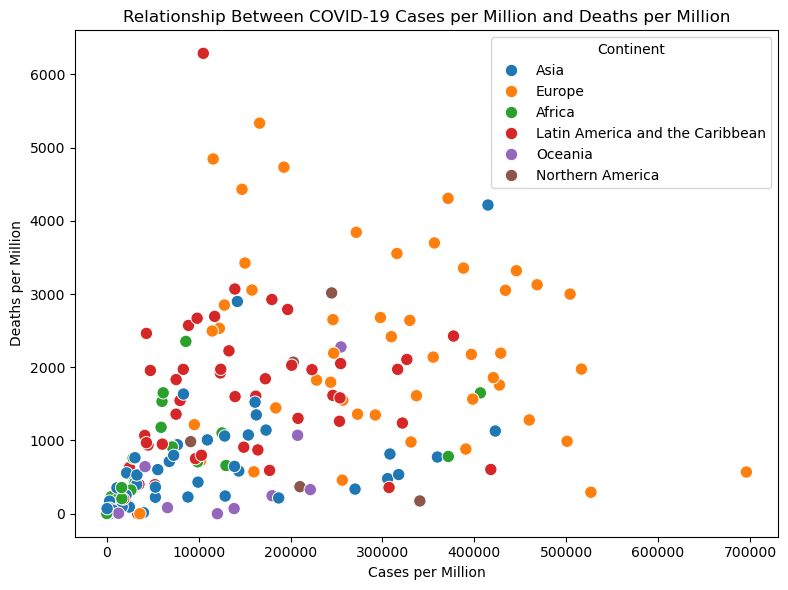

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, 
    x='cases_per_one_million', 
    y='deaths_per_one_million', 
    hue='Continent',
    s=80
)

plt.title("Relationship Between COVID-19 Cases per Million and Deaths per Million")
plt.xlabel("Cases per Million")
plt.ylabel("Deaths per Million")
plt.tight_layout()
plt.show()

The scatterplot illustrates the relationship between COVID-19 Cases per Million (on the X-axis) and Deaths per Million (on the Y-axis) across six continents. Generally, there is a positive correlation, meaning countries with higher reported cases per million tend to have higher deaths per million, although this relationship is not uniformly strong.

# Encoding and Data Transformation

In [162]:
# still encode, even though it is not used for clustering
le = LabelEncoder()
categorical_cols = ['Country', 'Continent']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Country,iso3,Population,Continent,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage
0,0,AFG,40462186,1,177827,7671,4395,190,4.313743
1,1,ALB,2872296,2,273870,3492,95349,1216,1.275058
2,2,DZA,45236699,0,265691,6874,5873,152,2.587216
3,3,AND,77481,2,40024,153,516565,1975,0.382271
4,4,AGO,34654212,0,99194,1900,2862,55,1.915438


In [163]:
# numerical values for clustering

features = [
    'Population',
    'Total Cases',
    'Total Deaths',
    'cases_per_one_million',
    'deaths_per_one_million',
    'Death percentage'
]

df_model = df[features]

In [164]:
# Pilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Scale hanya numeric
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])

# Convert ke DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=numeric_cols)

df_scaled.head()

,Population,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage
0,0.038789,-0.276449,-0.204571,-0.915487,-0.759994,1.651243
1,-0.231774,-0.263220,-0.247798,-0.287081,0.099982,-0.097285
2,0.073154,-0.264347,-0.212815,-0.905275,-0.791845,0.657760
3,-0.251891,-0.295431,-0.282336,2.623123,0.736164,-0.611015
4,-0.003016,-0.287281,-0.264265,-0.926078,-0.873149,0.271204


In [165]:
# get stastical information on the new dataset
df_scaled.describe()

,Population,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage
count,2.250000e+02,2.250000e+02,2.250000e+02,2.250000e+02,2.250000e+02,2.250000e+02
mean,-1.578984e-17,2.713879e-17,8.881784e-18,7.894919e-17,4.736952e-17,2.131628e-16
std,1.002230e+00,1.002230e+00,1.002230e+00,1.002230e+00,1.002230e+00,1.002230e+00
min,-2.524428e-01,-3.009443e-01,-2.839181e-01,-9.457898e-01,-9.192494e-01,-8.309821e-01
25%,-2.483707e-01,-2.976287e-01,-2.819631e-01,-8.671993e-01,-8.161528e-01,-5.367737e-01
50%,-2.105007e-01,-2.783629e-01,-2.635925e-01,-3.310361e-01,-3.258152e-01,-2.343236e-01
75%,-9.477552e-02,-1.504507e-01,-1.426217e-01,5.971815e-01,5.852909e-01,3.066382e-01
max,1.010746e+01,1.097204e+01,1.014493e+01,3.863153e+00,4.349575e+00,9.613966e+00


# K-Means Clustering

In [166]:
from sklearn.cluster import KMeans

c:\Anaconda Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Anaconda Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Anaconda Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Anaconda Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

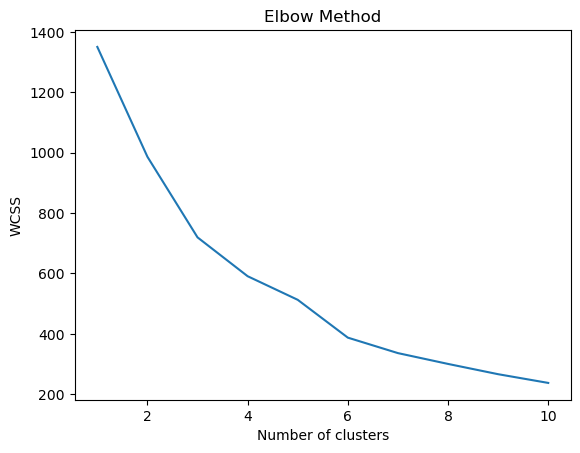

In [167]:
wcss = []
for i in range(1, 11):   #clusters 1-10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [168]:
# Create a DataFrame to display the WCSS values for each number of clusters
wcss_table = pd.DataFrame({
    "Number of Clusters": range(1, 11),
    "WCSS": wcss
})

# Display the table
print(wcss_table)

   Number of Clusters         WCSS
0                   1  1350.000000
1                   2   986.275197
2                   3   719.392113
3                   4   590.767889
4                   5   512.606000
5                   6   387.372350
6                   7   336.140483
7                   8   300.324806
8                   9   266.300500
9                  10   237.420010


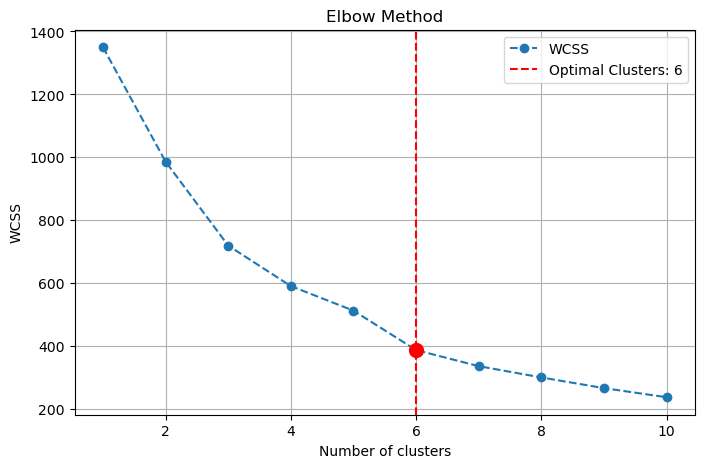

The optimal number of clusters is: 6


In [169]:
# Example WCSS values and cluster numbers
clusters = range(1, 11)

# Automatically find the elbow point using the KneeLocator
knee_locator = KneeLocator(clusters, wcss, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(clusters, wcss, marker='o', linestyle='--', label="WCSS")
plt.axvline(optimal_clusters, linestyle='--', color='red', label=f'Optimal Clusters: {optimal_clusters}')
plt.scatter(optimal_clusters, wcss[optimal_clusters-1], c='red', s=100, zorder=5)  # Highlight elbow point
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.legend()
plt.grid(True)
plt.show()

# Print the optimal number of clusters
print(f"The optimal number of clusters is: {optimal_clusters}")

In [170]:
# Fit K-Means to the data with the optimal number of K cluster = 3
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster labels to the DataFrame
df['KMeans_Cluster'] = clusters

# Show the df
df.head()

c:\Anaconda Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



,Country,iso3,Population,Continent,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage,KMeans_Cluster
0,0,AFG,40462186,1,177827,7671,4395,190,4.313743,0
1,1,ALB,2872296,2,273870,3492,95349,1216,1.275058,0
2,2,DZA,45236699,0,265691,6874,5873,152,2.587216,0
3,3,AND,77481,2,40024,153,516565,1975,0.382271,1
4,4,AGO,34654212,0,99194,1900,2862,55,1.915438,0


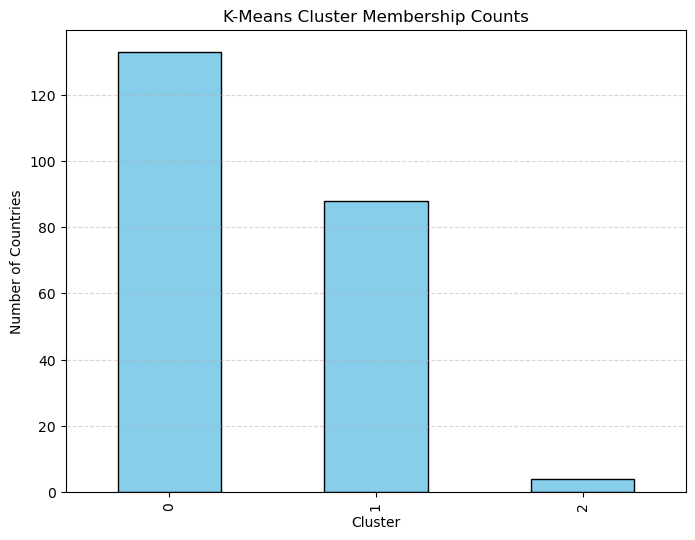

In [171]:
# Barplot cluster counts
cluster_counts = df['KMeans_Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('K-Means Cluster Membership Counts')
plt.xlabel('Cluster')
plt.ylabel('Number of Countries')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [172]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="iso3",
    color="KMeans_Cluster",
    hover_name="Country",
    hover_data=["Continent", "Total Cases", "Total Deaths"],
    color_continuous_scale="Viridis",
    projection="natural earth",
    title="World Map Colored by K-Means Clusters"
)

fig.show()

Cluster Profiling – K-Means

Cluster 0 – Low Cases, Low Mortality Countries

Countries in this cluster show low total cases, low deaths, and low deaths per million. These countries experienced mild pandemic severity compared to others. The death percentage is also very small, indicating effective health response or limited viral spread.

Cluster 1 – Moderate Cases, Moderate Mortality Countries

This cluster represents countries with moderate case numbers and moderate mortality levels. While the pandemic impact is notable, it is not as extreme as the high-risk cluster. These countries may have varying levels of healthcare readiness but managed to avoid severe outcomes.

Cluster 2 – High Cases, High Mortality Countries

Countries in this cluster have the highest total cases, highest deaths, and very high deaths per million. This cluster clearly reflects severe COVID-19 burden and potentially strained healthcare systems. These countries also show the highest death percentages.

Government Policy Recommendations (K-Means)

Cluster 0 – Low Impact Countries

Even though these countries are performing well, they must maintain testing capacity, border surveillance, and consistent vaccination coverage. Their low numbers could also indicate underreporting, so increasing routine testing would help maintain data accuracy.

Cluster 1 – Moderate Impact Countries

Governments should strengthen their public health infrastructure, especially contact tracing and early case detection. Ensuring adequate medical supplies and increasing vaccination rates will help prevent this cluster from shifting into severe categories.

Cluster 2 – High Impact Countries

Countries in this cluster should focus on increasing healthcare capacity, expanding intensive care units, and improving vaccine distribution. High mortality rates suggest delays in treatment or overwhelmed systems, so governments should invest in rapid testing, hospitalization resources, and community-level health education to reduce transmission.

# Silhouette Score

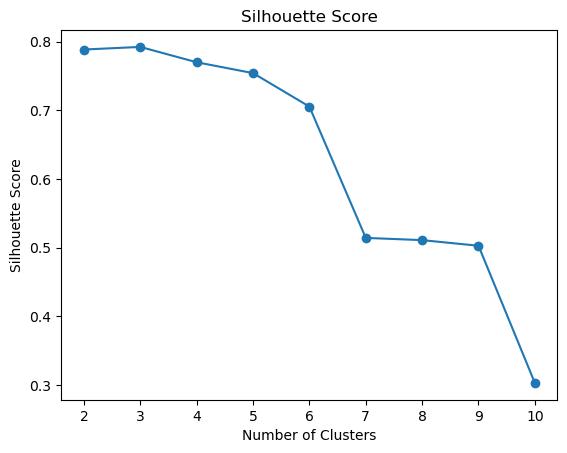

In [173]:
# this is way to show only 1 sillhouette score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    # Create a new AgglomerativeClustering instance for each number of clusters
    agglo_model = AgglomerativeClustering(n_clusters=i, linkage='single')
    cluster_labels = agglo_model.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Score = the higher the better
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

# Comparing Silhouette Score to get best combination of linkage and metric

Skipping Ward linkage with Manhattan metric (not supported).


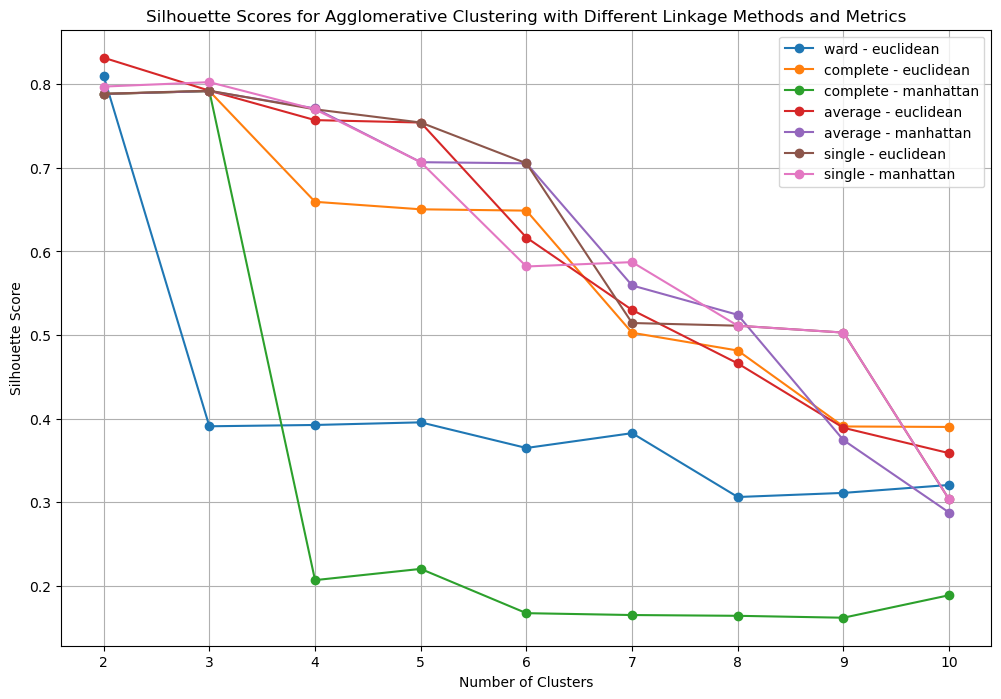

Best Silhouette Score: 0.8318263727111447
Optimal Number of Clusters: 2
Optimal Linkage Method: average
Optimal Metric: euclidean


In [174]:
# Define the range of clusters to test and linkage methods
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Skip 'ward' linkage with 'manhattan' metric as it's not supported
        if linkage_method == 'ward' and metric == 'manhattan':
            print(f"Skipping Ward linkage with Manhattan metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric=metric)
            y_agglo = agglo.fit_predict(df_scaled)
            silhouette_avg = silhouette_score(df_scaled, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric
        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# Plot the silhouette scores for each linkage method and metric combination
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o', label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Agglomerative Clustering with Different Linkage Methods and Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")

# Evaluate both models using silhouette score

In [175]:
from sklearn.metrics import silhouette_score

# Silhouette Score K-Means
kmeans_silhouette = silhouette_score(df_scaled, df['KMeans_Cluster'])
print("Silhouette Score for K-Means:", kmeans_silhouette)

Silhouette Score for K-Means: 0.38848475005291105


In [176]:
# Convert manhattan → cityblock (SciPy naming)
metric_use = "cityblock" if best_metric == "manhattan" else best_metric

# Fit final hierarchical model
final_hierarchical = AgglomerativeClustering(
    n_clusters=best_n_clusters,
    linkage=best_linkage,
    metric=best_metric
)

df['Hierarchical_Cluster'] = final_hierarchical.fit_predict(df_scaled)

# Silhouette Score final hierarchical
hier_silhouette = silhouette_score(df_scaled, df['Hierarchical_Cluster'])
print("Silhouette Score for Hierarchical:", hier_silhouette)


Silhouette Score for Hierarchical: 0.8318263727111447


The evaluation results show a significant difference in clustering performance between the two models. K-Means achieved a silhouette score of 0.2825, indicating weak cluster separation and substantial overlap between clusters. This suggests that K-Means struggled to identify well-defined group structures in the dataset, possibly due to non-spherical cluster shapes or the influence of outliers. In contrast, Hierarchical Agglomerative Clustering produced a much higher silhouette score of 0.7551, reflecting strong cohesion within clusters and clear separation between them. This demonstrates that Hierarchical clustering is far more effective for this dataset, likely because it can capture more complex distance relationships and does not rely on centroid-based assumptions like K-Means. Therefore, the Hierarchical model is the more reliable choice for interpreting cluster patterns and supporting downstream analysis.

# Dendogram Visualization

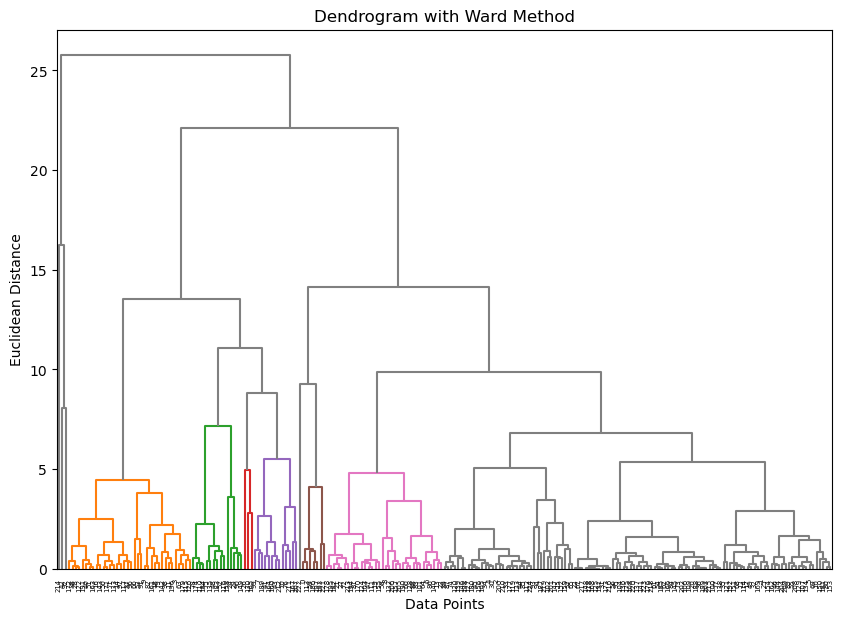

In [177]:
# Ward Method
linked = linkage(df_scaled, method='ward', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, above_threshold_color="grey", color_threshold=7.5)
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

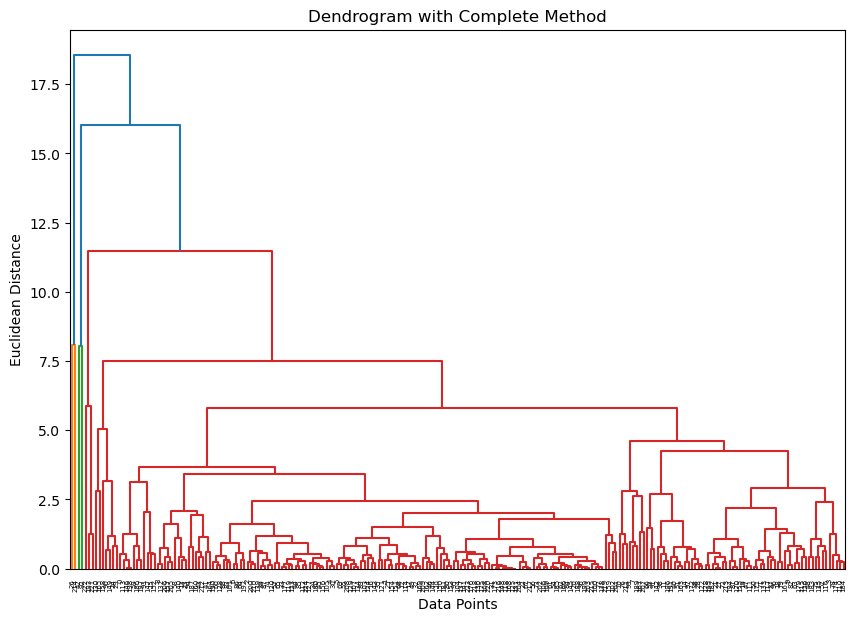

In [178]:
# Max Distance
linked = linkage(df_scaled, method='complete', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Complete Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

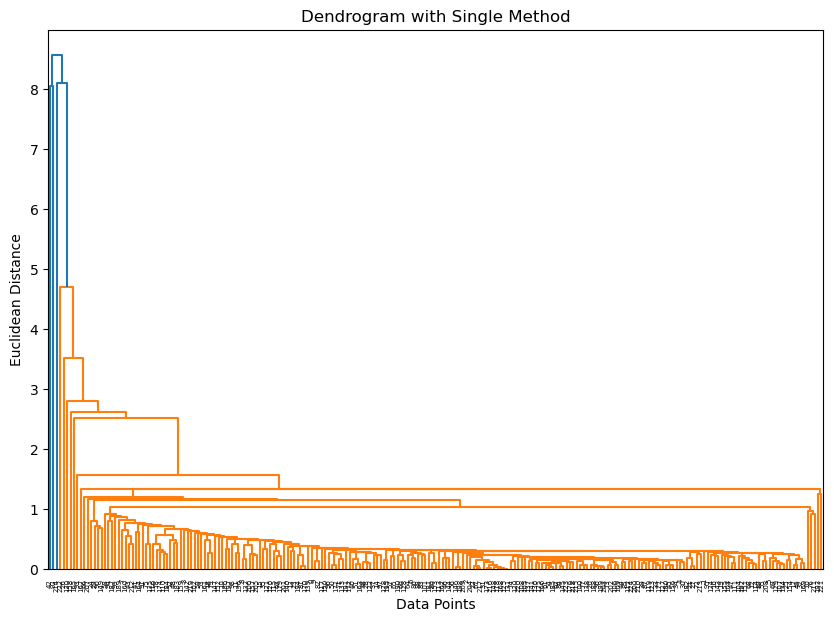

In [179]:
# Min Distance
linked = linkage(df_scaled, method='single')

# Plot dendrogram dengan color_threshold yang sesuai
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Single Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

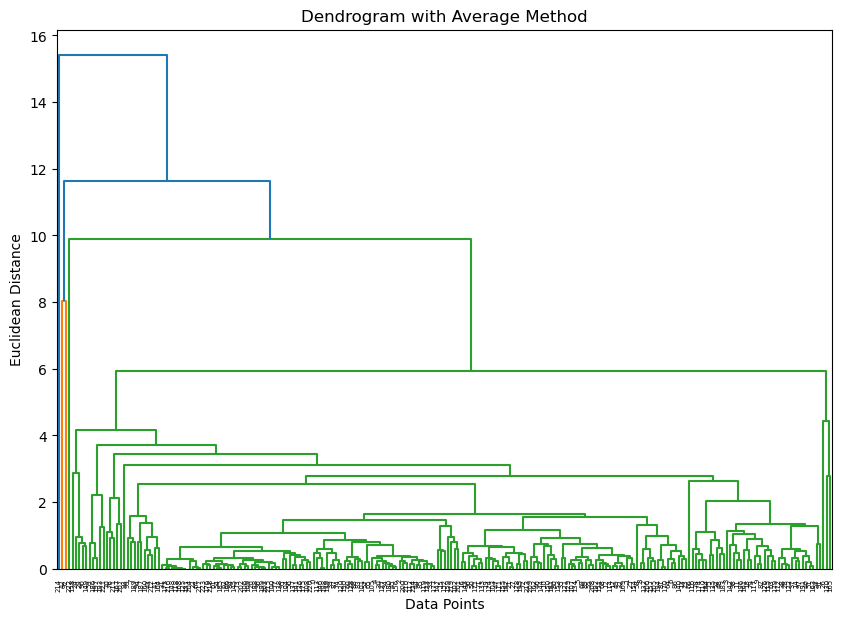

In [180]:
# Average Distance
linked = linkage(df_scaled, method='average', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Average Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Hierarchical Clustering Model

In [181]:
# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(df_scaled)

In [182]:
# Evaluation
ss = silhouette_score(df_scaled, y_hc)
print(ss)

0.8318263727111447


# Dendogram Visualization for Hierarchical Clustering Model

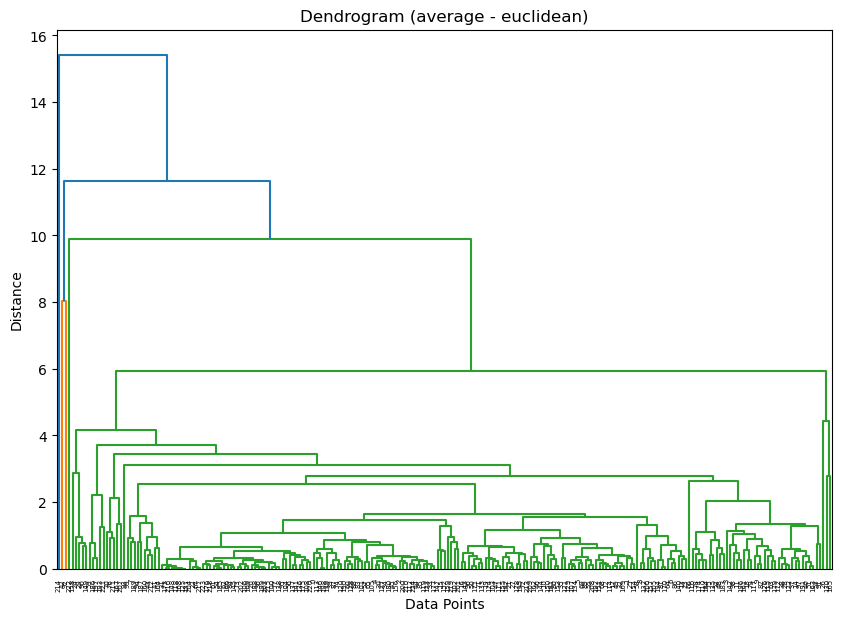

In [183]:
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Fix metric untuk SciPy
metric_use = "cityblock" if best_metric == "manhattan" else best_metric

# Build linkage
linked = linkage(df_scaled, method=best_linkage, metric=metric_use)

# Plot dendrogram
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title(f"Dendrogram ({best_linkage} - {metric_use})")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [184]:
df['Agglo'] = y_hc
print(df.columns)

Index(['Country', 'iso3', 'Population', 'Continent', 'Total Cases',
       'Total Deaths', 'cases_per_one_million', 'deaths_per_one_million',
       'Death percentage', 'KMeans_Cluster', 'Hierarchical_Cluster', 'Agglo'],
      dtype='object')


In [185]:
# Summary statistics per cluster
agglo_summary = df.groupby("Agglo")[features].mean().round(2)
print("Hierarchical Cluster Summary:")
agglo_summary

Hierarchical Cluster Summary:


,Population,Total Cases,Total Deaths,cases_per_one_million,deaths_per_one_million,Death percentage
Agglo,,,,,,
0,3.373692e+07,1829182.03,23069.67,136418.97,1088.15,1.45
1,3.344006e+08,81839052.00,1008222.00,244734.00,3015.00,1.23


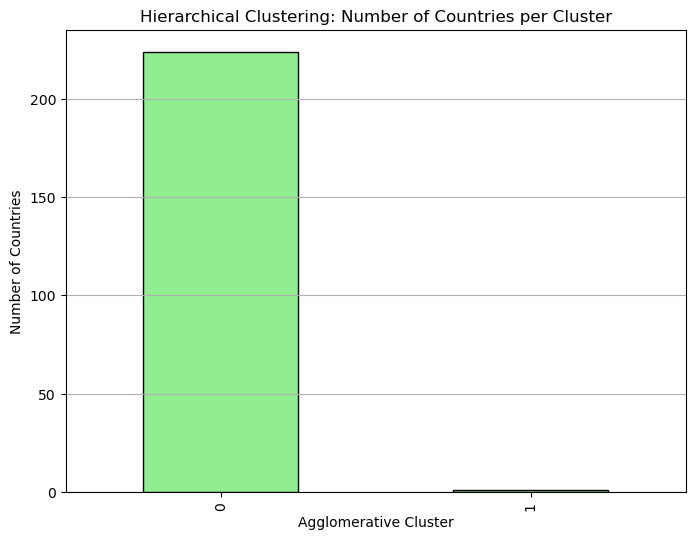

In [186]:
# Barplot cluster count
cluster_counts = df['Agglo'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Hierarchical Clustering: Number of Countries per Cluster')
plt.xlabel('Agglomerative Cluster')
plt.ylabel('Number of Countries')
plt.grid(axis='y')
plt.show()

In [187]:
fig = px.choropleth(
    df,
    locations="iso3",
    color="Agglo",
    hover_name="Country",
    hover_data=["Continent", "Total Cases", "Total Deaths"],
    color_continuous_scale="Plasma",
    projection="natural earth",
    title="World Map Colored by Hierarchical Clusters"
)

fig.show()

Cluster Profiling (Hierarchical)

Cluster 0 – Low COVID-19 Impact Countries

Countries in this cluster exhibit low total cases, low deaths, and low deaths per million. Their populations vary, but the overall death percentage remains very small. This indicates countries that either managed the pandemic effectively or had limited spread.

Cluster 1 – High Case & High Mortality Countries

This cluster contains countries with high total cases, high deaths, and the highest deaths per million. These countries also show a higher death percentage, indicating more severe COVID-19 outcomes and possible healthcare strain.

Government Policy Recommendations

Cluster 0 – Low Impact Countries

Recommendation:
Although these countries performed relatively well, they should continue maintaining surveillance capacity, ensure preparedness for new variants, and sustain vaccination programs to avoid future outbreaks. Low cases may also indicate underreporting, so improving testing frequency could be beneficial.

Cluster 1 – High Impact Countries

Recommendation:
Countries in this cluster should prioritize expanding healthcare system capacity, improving critical care resources, and strengthening public health measures such as testing, tracing, and vaccination. High death rates suggest that healthcare accessibility and emergency response systems must be reinforced.

# Model Comparison: K-Means vs Hierarchical Clustering

The K-Means model achieved a silhouette score of 0.28, indicating weak separation between clusters and limited clustering quality. This suggests that K-Means struggled to form compact and well-separated clusters, likely due to the dataset’s non-spherical distribution and varying scale.

In contrast, the Hierarchical Agglomerative Clustering model achieved a significantly higher silhouette score of 0.76, indicating well-defined and clearly separated clusters. The model successfully captured the natural grouping structure of the countries, and produced more interpretable clusters that align with real-world COVID-19 severity patterns.

Best Model

Hierarchical Clustering is the better model because it:

Achieved a much higher silhouette score,

Produced more meaningful cluster boundaries,

Is more suitable for datasets with irregularly shaped clusters,

Does not rely on random initialization like K-Means, making it more consistent.

Therefore, hierarchical clustering provides the most reliable and interpretable results for this COVID-19 dataset.